In [376]:
import cv2
import numpy as np
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torch

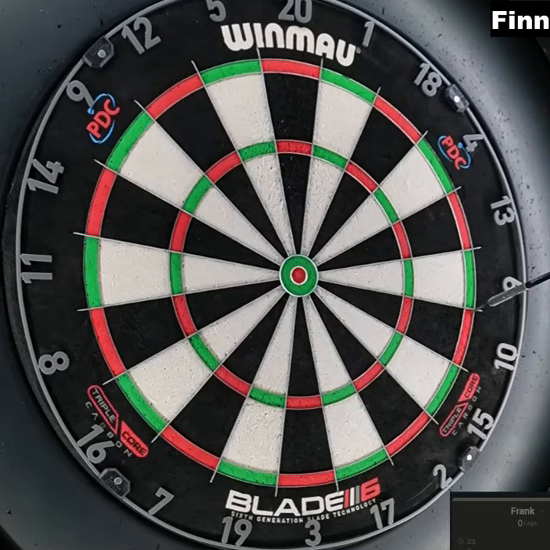

In [377]:
ref_img = Image.open("my_unlabelled/vids/frames_0001/output_0121.jpg").convert("RGB")
img = Image.open("my_unlabelled/vids/frames_0001/output_0125.jpg").convert("RGB")
ref_img

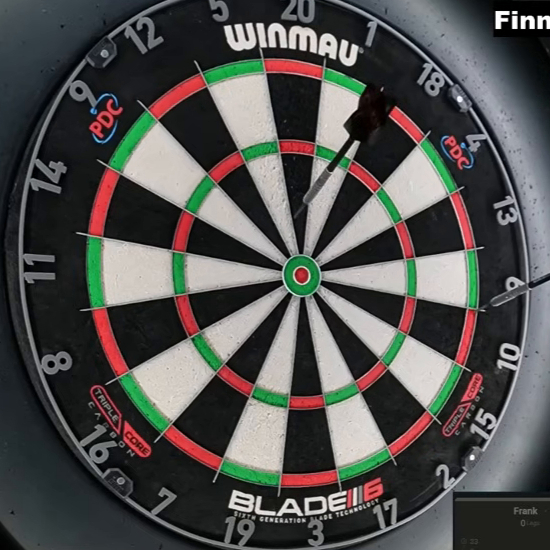

In [378]:
img

In [379]:
model = DetrForObjectDetection.from_pretrained("center_scale/checkpoint-32000/")
image_processor = DetrImageProcessor(size={"shortest_edge": 768, "longest_edge": 768})

c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current 

In [380]:
def forward(img):
    inputs = image_processor(images=img, return_tensors="pt", do_resize=True)
    outputs = model(**inputs)
    target_sizes = torch.tensor([img.size[::-1]])
    boxes, logits = outputs.pred_boxes[0].detach().numpy(), outputs.logits[0].detach()
    keypoints = boxes[:, :2] * img.size
    corners = np.array([keypoints[logits[:, corner].argmax().item()] for corner in range(4)])
    return {"corners": corners, "keypoints": keypoints, "logits": logits}

In [381]:
def transform_image(image, corners, size=768, **kwargs):
    tgt = np.array([[0.88, 0.5], [0.5, 0.12], [0.12, 0.5], [0.5, 0.88]]) * size
    transform, _ = cv2.findHomography(corners, tgt)
    transformed_image = Image.fromarray(cv2.warpPerspective(np.array(image), transform, (size, size)))
    return transformed_image

In [382]:
colors = ["red", "blue", "green", "yellow", "orange"]

In [383]:
t_ref = transform_image(ref_img, **forward(ref_img))

In [384]:
t_img = transform_image(img, **forward(img))

In [385]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt

In [386]:
def compare(img0, img1):
    ssim_maps = []
    scores = []
    for ch in range(3):  # R, G, B
        score, ssim_map = ssim(np.array(img0)[:,:,ch], np.array(img1)[:,:,ch], full=True)
        scores.append(score)
        ssim_maps.append(ssim_map)
    ssim_rgb = np.stack(ssim_maps, axis=-1)
    return np.mean(scores), ssim_rgb.mean(axis=-1)

In [387]:
warp_matrix = np.eye(2, 3, dtype=np.float32)
img_gray, ref_gray = cv2.cvtColor(np.array(t_img), cv2.COLOR_RGB2GRAY), cv2.cvtColor(np.array(t_ref), cv2.COLOR_RGB2GRAY)
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 5000, 1e-6)
(cc, warp_matrix) = cv2.findTransformECC(img_gray, ref_gray, warp_matrix, cv2.MOTION_AFFINE, criteria)

aligned = cv2.warpAffine(np.array(t_ref), warp_matrix, (img_gray.shape[1], img_gray.shape[0]),
                         flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
aligned.shape, np.array(t_img).shape

((768, 768, 3), (768, 768, 3))

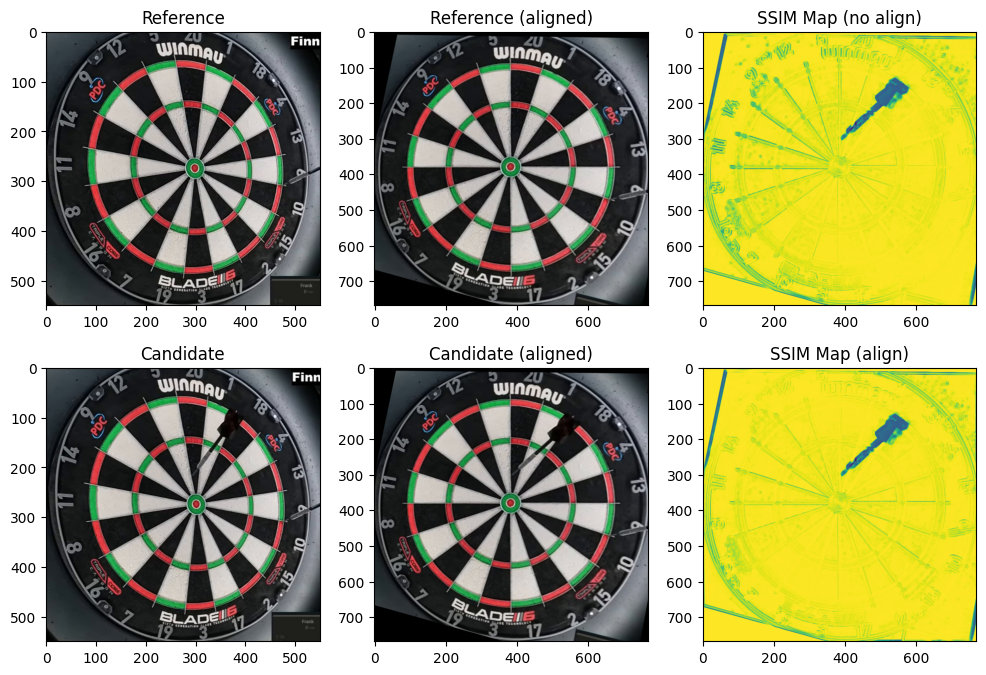

In [388]:
score, ssim_map = compare(aligned, t_img)
score, ssim_map_old = compare(t_ref, t_img)
plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.title("Reference"); plt.imshow(ref_img)
plt.subplot(2,3,2); plt.title("Reference (aligned)"); plt.imshow(aligned)
plt.subplot(2,3,3); plt.title("SSIM Map (no align)"); plt.imshow(ssim_map_old)
plt.subplot(2,3,4); plt.title("Candidate"); plt.imshow(img)
plt.subplot(2,3,5); plt.title("Candidate (aligned)"); plt.imshow(t_img)
plt.subplot(2,3,6); plt.title("SSIM Map (align)"); plt.imshow(ssim_map)
plt.show()

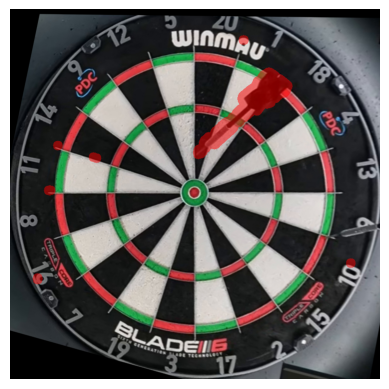

In [389]:
from scipy.ndimage import binary_dilation

thresh = 0.3
radius = 10

# Mark where SSIM is below threshold
mask = ssim_map < thresh
Y, X = np.ogrid[:ssim_map.shape[1], :ssim_map.shape[0]]
X =  (X / ssim_map.shape[0]) * 2 - 1
Y =  (Y / ssim_map.shape[1]) * 2 - 1
center_mask = (X**2 + Y**2) <= 0.95
mask *= center_mask

# Create circular structuring element
y,x = np.ogrid[-radius:radius+1, -radius:radius+1]
selem = x**2 + y**2 <= radius**2

# Dilate mask with circular kernel
allowed = binary_dilation(mask, structure=selem)

overlay = np.array(t_img)
overlay[allowed] = [255, 0, 0]   # pure red

# Blend original and overlay
blended = cv2.addWeighted(np.array(t_img), 0.5, overlay, 0.5, 0)

plt.imshow(blended)
plt.axis("off")
plt.show()

torch.Size([100, 6])
2.871319793484872e-06 92 384 (550, 550)


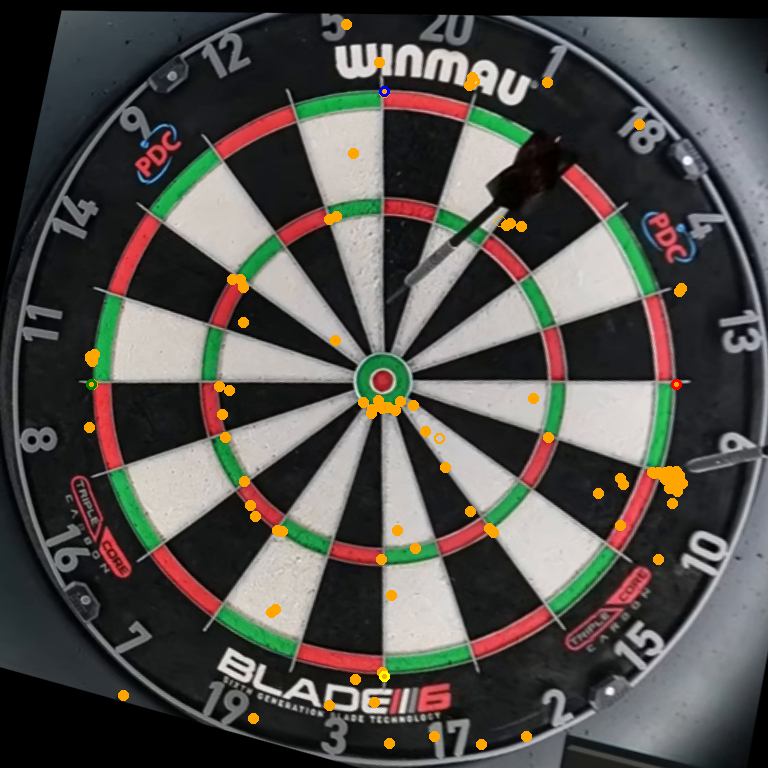

In [ ]:
result = forward(t_img)
r = 5
prob = torch.nn.functional.softmax(result["logits"], -1)
print(result["logits"].shape)
keypoints = result["keypoints"].round().astype(int)
allowed_kp = allowed[keypoints[:, 1], keypoints[:, 0]]
keypoints, prob = keypoints[allowed_kp], prob[allowed_kp]
draw = ImageDraw.Draw(t_img)
idx = prob[:, 4].argsort(descending=True)
# print(idx.shape)
for i in idx:
    x,y = keypoints[i]
    score = prob[i, 4].item()
    # print(score, x,y, img.size)
    draw.ellipse((x-r, y-r, x+r, y+r), outline=colors[4], width=len(idx)-i)
print(score, x,y, img.size)
draw.ellipse((x-r, y-r, x+r, y+r), outline=colors[4], width=int(score*10)+1)
for i, (x,y) in enumerate(result["corners"]):
    draw.ellipse((x-r, y-r, x+r, y+r), outline=colors[i], width=3)   
t_img